# 个股日线数据涨跌幅预测与 Test 集效果评估

本 Notebook 按照量化研究的核心任务，对 A 股个股日线数据进行监督预测建模。不同于前一版只做市场状态识别，本版本重点关注模型是否能够在 Test 集上预测未来涨跌幅，以及预测股票未来上涨或不上涨。

具体思路是：首先读取并整理个股日线数据，构造个股层面的历史收益、波动率、振幅、换手率、成交额变化、市值等特征；同时合并市场层面的收益、波动、上涨比例等特征，以及前期 HMM 识别得到的市场状态变量。然后构造未来 1 日收益率作为回归预测目标，构造未来 1 日是否上涨作为分类预测目标。

在模型评估上，本文按照时间顺序划分 Train 集和 Test 集。模型只使用 2020--2024 年的数据进行训练，并在 2025--2026 年的 Test 集上进行验证，避免未来信息泄露。最终主要观察 Test 集上的 IC、Rank IC、方向准确率、AUC、Top 组收益和 Top-Bottom 多空收益，用于判断模型是否真正具有预测效果。

本 Notebook 同时比较两个版本的模型：一个是不加入市场状态变量的 baseline 模型，另一个是在特征中加入 HMM 状态概率的 with_state 模型。通过比较二者在 Test 集上的表现，可以判断市场状态识别结果是否对涨跌幅预测具有增量帮助。

In [48]:
# Cell 1：导入包与路径设置

from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")

# 现在项目主文件夹改成 v2
PROJECT_DIR = Path("/Users/runtianzhou/Turing_AI_v2")

# 数据可以继续用旧项目里的 data_extracted
# 因为原始数据很大，没必要复制一份
DATA_DIR = Path("/Users/runtianzhou/Turing_AI/data_extracted")

# 状态识别结果也可以先读旧项目里的
STATE_FILE = Path("/Users/runtianzhou/Turing_AI/state_recognition_output/hmm_state_result.csv")

# v2 的所有输出都保存到 Turing_AI_v2
OUT_DIR = PROJECT_DIR / "prediction_output_v2"
FIG_DIR = PROJECT_DIR / "figures"
REPORT_DIR = PROJECT_DIR / "reports"

for d in [PROJECT_DIR, OUT_DIR, FIG_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("STATE_FILE:", STATE_FILE)
print("OUT_DIR:", OUT_DIR)
print("FIG_DIR:", FIG_DIR)
print("REPORT_DIR:", REPORT_DIR)

PROJECT_DIR: /Users/runtianzhou/Turing_AI_v2
DATA_DIR: /Users/runtianzhou/Turing_AI/data_extracted
STATE_FILE: /Users/runtianzhou/Turing_AI/state_recognition_output/hmm_state_result.csv
OUT_DIR: /Users/runtianzhou/Turing_AI_v2/prediction_output_v2
FIG_DIR: /Users/runtianzhou/Turing_AI_v2/figures
REPORT_DIR: /Users/runtianzhou/Turing_AI_v2/reports


In [49]:
# Cell 2：工具函数

def parse_any_date(x):
    """
    兼容多种日期格式：
    20200102
    2020-01-02
    2020/01/02
    2020.01.02
    """
    if pd.isna(x):
        return pd.NaT

    s = str(x).strip()

    # 处理 20200102.0 这种情况
    if re.fullmatch(r"\d+\.0", s):
        s = s.split(".")[0]

    # 优先提取 8 位数字日期
    m = re.search(r"(20\d{6})", s)
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")

    # 再处理 2020-01-02 / 2020/01/02 / 2020.01.02
    m = re.search(r"(20\d{2})[-_/\.](\d{1,2})[-_/\.](\d{1,2})", s)
    if m:
        y, mo, d = m.groups()
        return pd.to_datetime(f"{y}-{int(mo):02d}-{int(d):02d}", errors="coerce")

    return pd.to_datetime(s, errors="coerce")


def parse_date_from_df_or_name(df: pd.DataFrame, path: Path, date_col: str = None):
    """
    优先从数据里的日期列读取；
    如果失败，就从文件名或路径中提取日期。
    """
    # 1. 从日期列读取
    if date_col is not None and date_col in df.columns and len(df) > 0:
        non_na = df[date_col].dropna()
        if len(non_na) > 0:
            dt = parse_any_date(non_na.iloc[0])
            if pd.notna(dt):
                return dt

    # 2. 从完整路径中提取日期
    path_str = str(path)

    dt = parse_any_date(path_str)
    if pd.notna(dt):
        return dt

    return pd.NaT

In [50]:
# Cell 3：读取日线数据

def load_daily_stock_data(data_dir: Path):
    csv_files = sorted(data_dir.rglob("*.csv"))
    
    if len(csv_files) == 0:
        raise FileNotFoundError(f"没有在 {data_dir} 找到CSV。")

    print("发现CSV数量：", len(csv_files))
    print("第一个文件：", csv_files[0])

    code_col = "secID"
    ret_col = "chgPct"
    open_col = "openPrice"
    high_col = "highestPrice"
    low_col = "lowestPrice"
    close_col = "closePrice"
    preclose_col = "preClosePrice"
    amount_col = "turnoverValue"
    turnover_col = "turnoverRate"
    mcap_col = "negMarketValue"
    isopen_col = "isOpen"

    keep_cols = [
        code_col, ret_col, open_col, high_col, low_col, close_col,
        preclose_col, amount_col, turnover_col, mcap_col, isopen_col
    ]

    rows = []
    t0 = time.time()

    for i, f in enumerate(csv_files):
        try:
            df = read_csv_safely(f)
        except Exception as e:
            print("读取失败：", f, e)
            continue

        date = pd.to_datetime(f.stem, format="%Y%m%d", errors="coerce")

        if pd.isna(date):
            print("日期解析失败：", f)
            continue

        missing = [c for c in keep_cols if c not in df.columns]
        if missing:
            print("字段缺失，跳过：", f, missing)
            continue

        df = df[keep_cols].copy()

        if isopen_col in df.columns:
            df = df[df[isopen_col] == 1].copy()

        # 关键修改：先建立和 df 一样的 index，再赋值
        out = pd.DataFrame(index=df.index)

        out["date"] = date
        out["code"] = df[code_col].astype(str)
        out["ret"] = pd.to_numeric(df[ret_col], errors="coerce")

        out["open"] = pd.to_numeric(df[open_col], errors="coerce")
        out["high"] = pd.to_numeric(df[high_col], errors="coerce")
        out["low"] = pd.to_numeric(df[low_col], errors="coerce")
        out["close"] = pd.to_numeric(df[close_col], errors="coerce")
        out["preclose"] = pd.to_numeric(df[preclose_col], errors="coerce")
        out["amount"] = pd.to_numeric(df[amount_col], errors="coerce")
        out["turnover"] = pd.to_numeric(df[turnover_col], errors="coerce")
        out["mcap"] = pd.to_numeric(df[mcap_col], errors="coerce")

        out = out.dropna(subset=["date", "code", "ret"])
        rows.append(out)

        if (i + 1) % 300 == 0:
            print(f"已读取 {i+1}/{len(csv_files)} 个文件，用时 {time.time() - t0:.1f} 秒")

    data = pd.concat(rows, ignore_index=True)
    data = data.sort_values(["code", "date"]).reset_index(drop=True)

    print("合并后数据形状：", data.shape)
    print("日期范围：", data["date"].min(), "到", data["date"].max())
    print("股票数：", data["code"].nunique())

    return data


stock_df = load_daily_stock_data(DATA_DIR)

发现CSV数量： 1476
第一个文件： /Users/runtianzhou/Turing_AI/data_extracted/daily_temp3/20200102.csv
已读取 300/1476 个文件，用时 3.2 秒
已读取 600/1476 个文件，用时 6.8 秒
已读取 900/1476 个文件，用时 10.5 秒
已读取 1200/1476 个文件，用时 14.6 秒
合并后数据形状： (6950493, 11)
日期范围： 2020-01-02 00:00:00 到 2026-02-02 00:00:00
股票数： 5392


In [51]:
# Cell 4：特征工程

# 个股振幅特征
if {"high", "low", "preclose"}.issubset(stock_df.columns):
    stock_df["amplitude"] = (
        stock_df["high"] - stock_df["low"]
    ) / stock_df["preclose"].replace(0, np.nan)
else:
    stock_df["amplitude"] = np.nan

# 如果部分字段不存在，先补成空值
if "amount" not in stock_df.columns:
    stock_df["amount"] = np.nan

if "turnover" not in stock_df.columns:
    stock_df["turnover"] = np.nan

if "mcap" not in stock_df.columns:
    stock_df["mcap"] = np.nan

# 个股过去收益特征
stock_df["ret_lag1"] = stock_df.groupby("code")["ret"].shift(1)
stock_df["ret_lag2"] = stock_df.groupby("code")["ret"].shift(2)

stock_df["ret_5d"] = stock_df.groupby("code")["ret"].transform(
    lambda x: x.rolling(5).sum()
)

stock_df["ret_20d"] = stock_df.groupby("code")["ret"].transform(
    lambda x: x.rolling(20).sum()
)

stock_df["vol_20d"] = stock_df.groupby("code")["ret"].transform(
    lambda x: x.rolling(20).std()
)

stock_df["amp_5d"] = stock_df.groupby("code")["amplitude"].transform(
    lambda x: x.rolling(5).mean()
)

stock_df["turnover_5d"] = stock_df.groupby("code")["turnover"].transform(
    lambda x: x.rolling(5).mean()
)

stock_df["amount_log"] = np.log(stock_df["amount"].replace(0, np.nan))
stock_df["amount_chg_5d"] = stock_df.groupby("code")["amount_log"].diff(5)

stock_df["mcap_log"] = np.log(stock_df["mcap"].replace(0, np.nan))

print("个股特征完成：", stock_df.shape)

个股特征完成： (6950493, 22)


In [52]:
# Cell 5：构造市场层面特征

market_daily = stock_df.groupby("date").agg(
    market_ret=("ret", "mean"),
    market_up_ratio=("ret", lambda x: (x > 0).mean()),
    market_cross_vol=("ret", "std"),
    market_amp=("amplitude", "mean"),
    market_amount=("amount", "sum"),
).reset_index()

market_daily["market_ret_5d"] = market_daily["market_ret"].rolling(5).sum()
market_daily["market_ret_20d"] = market_daily["market_ret"].rolling(20).sum()
market_daily["market_vol_20d"] = market_daily["market_ret"].rolling(20).std()

market_daily["market_amount_log"] = np.log(
    market_daily["market_amount"].replace(0, np.nan)
)

market_daily["market_amount_chg_5d"] = market_daily["market_amount_log"].diff(5)

stock_df = stock_df.merge(market_daily, on="date", how="left")

print("合并市场特征后：", stock_df.shape)
stock_df.head()

合并市场特征后： (6950493, 32)


,date,code,ret,open,high,low,close,preclose,amount,turnover,...,market_ret,market_up_ratio,market_cross_vol,market_amp,market_amount,market_ret_5d,market_ret_20d,market_vol_20d,market_amount_log,market_amount_chg_5d
0,2020-01-02,000001.XSHE,0.0255,16.65,16.95,16.55,16.87,16.45,2.571196e+09,0.0079,...,0.018477,0.906952,0.020569,0.031255,7.512655e+11,NaN,NaN,NaN,27.345025,NaN
1,2020-01-03,000001.XSHE,0.0184,16.94,17.31,16.92,17.18,16.87,1.914495e+09,0.0058,...,0.005422,0.547715,0.022595,0.030087,6.952152e+11,NaN,NaN,NaN,27.267487,NaN
2,2020-01-06,000001.XSHE,-0.0064,17.01,17.34,16.91,17.07,17.18,1.477930e+09,0.0044,...,0.007729,0.550094,0.029729,0.037067,8.038776e+11,NaN,NaN,NaN,27.412713,NaN
3,2020-01-07,000001.XSHE,0.0047,17.13,17.28,16.95,17.15,17.07,1.247047e+09,0.0038,...,0.013591,0.801229,0.022522,0.031180,7.321135e+11,NaN,NaN,NaN,27.319201,NaN
4,2020-01-08,000001.XSHE,-0.0286,17.00,17.05,16.63,16.66,17.15,1.423609e+09,0.0044,...,-0.013230,0.192678,0.026100,0.036945,7.790306e+11,0.031988,NaN,NaN,27.381316,NaN


In [53]:
# Cell 6：合并之前识别出的市场状态变量

if STATE_FILE.exists():
    state_df = pd.read_csv(STATE_FILE)
    state_df["date"] = pd.to_datetime(state_df["date"])

    keep_state = [
        "date",
        "state_raw",
        "state_prob_0",
        "state_prob_1",
        "state_prob_2",
        "state_prob_3",
    ]
    keep_state = [c for c in keep_state if c in state_df.columns]

    stock_df = stock_df.merge(state_df[keep_state], on="date", how="left")

    print("已合并状态变量：", keep_state)
else:
    print("没有找到状态识别文件，将只做不含状态变量的预测。")
    stock_df["state_raw"] = np.nan

stock_df.head()

已合并状态变量： ['date', 'state_raw', 'state_prob_0', 'state_prob_1', 'state_prob_2', 'state_prob_3']


,date,code,ret,open,high,low,close,preclose,amount,turnover,...,market_ret_5d,market_ret_20d,market_vol_20d,market_amount_log,market_amount_chg_5d,state_raw,state_prob_0,state_prob_1,state_prob_2,state_prob_3
0,2020-01-02,000001.XSHE,0.0255,16.65,16.95,16.55,16.87,16.45,2.571196e+09,0.0079,...,NaN,NaN,NaN,27.345025,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,000001.XSHE,0.0184,16.94,17.31,16.92,17.18,16.87,1.914495e+09,0.0058,...,NaN,NaN,NaN,27.267487,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-06,000001.XSHE,-0.0064,17.01,17.34,16.91,17.07,17.18,1.477930e+09,0.0044,...,NaN,NaN,NaN,27.412713,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-07,000001.XSHE,0.0047,17.13,17.28,16.95,17.15,17.07,1.247047e+09,0.0038,...,NaN,NaN,NaN,27.319201,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-08,000001.XSHE,-0.0286,17.00,17.05,16.63,16.66,17.15,1.423609e+09,0.0044,...,0.031988,NaN,NaN,27.381316,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# Cell 7：构造预测目标 Y

# 预测目标1：未来1日涨跌幅
stock_df["target_ret_1d"] = stock_df.groupby("code")["ret"].shift(-1)

# 预测目标2：未来1日是否上涨
stock_df["target_up_1d"] = (stock_df["target_ret_1d"] > 0).astype(float)

# 清理异常值
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df[stock_df["target_ret_1d"].notna()].copy()

# 过滤极端收益，避免异常值影响模型
stock_df = stock_df[
    (stock_df["target_ret_1d"] > -0.25) &
    (stock_df["target_ret_1d"] < 0.25)
].copy()

print("构造预测目标后：", stock_df.shape)
print(stock_df[["date", "code", "ret", "target_ret_1d", "target_up_1d"]].head())

构造预测目标后： (6944907, 39)
        date         code     ret  target_ret_1d  target_up_1d
0 2020-01-02  000001.XSHE  0.0255         0.0184           1.0
1 2020-01-03  000001.XSHE  0.0184        -0.0064           0.0
2 2020-01-06  000001.XSHE -0.0064         0.0047           1.0
3 2020-01-07  000001.XSHE  0.0047        -0.0286           0.0
4 2020-01-08  000001.XSHE -0.0286         0.0078           1.0


In [55]:
# Cell 8：Train / Test 时间切分

stock_df["date"] = pd.to_datetime(stock_df["date"])

train_df = stock_df[stock_df["date"] <= pd.Timestamp("2024-12-31")].copy()
test_df = stock_df[stock_df["date"] >= pd.Timestamp("2025-01-01")].copy()

print("Train:", train_df["date"].min(), "到", train_df["date"].max(), train_df.shape)
print("Test :", test_df["date"].min(), "到", test_df["date"].max(), test_df.shape)

Train: 2020-01-02 00:00:00 到 2024-12-31 00:00:00 (5593415, 39)
Test : 2025-01-02 00:00:00 到 2026-01-30 00:00:00 (1351492, 39)


In [37]:
# Cell 9：设置特征列

base_features = [
    "ret",
    "ret_lag1",
    "ret_lag2",
    "ret_5d",
    "ret_20d",
    "vol_20d",
    "amplitude",
    "amp_5d",
    "turnover",
    "turnover_5d",
    "amount_chg_5d",
    "mcap_log",
    "market_ret",
    "market_ret_5d",
    "market_ret_20d",
    "market_vol_20d",
    "market_up_ratio",
    "market_cross_vol",
    "market_amp",
    "market_amount_chg_5d",
]

state_features = [
    c for c in [
        "state_prob_0",
        "state_prob_1",
        "state_prob_2",
        "state_prob_3",
    ]
    if c in stock_df.columns
]

features_without_state = [c for c in base_features if c in stock_df.columns]
features_with_state = features_without_state + state_features

print("不加入状态变量的特征数量：", len(features_without_state))
print(features_without_state)

print("\n加入状态变量后的特征数量：", len(features_with_state))
print(features_with_state)

不加入状态变量的特征数量： 20
['ret', 'ret_lag1', 'ret_lag2', 'ret_5d', 'ret_20d', 'vol_20d', 'amplitude', 'amp_5d', 'turnover', 'turnover_5d', 'amount_chg_5d', 'mcap_log', 'market_ret', 'market_ret_5d', 'market_ret_20d', 'market_vol_20d', 'market_up_ratio', 'market_cross_vol', 'market_amp', 'market_amount_chg_5d']

加入状态变量后的特征数量： 24
['ret', 'ret_lag1', 'ret_lag2', 'ret_5d', 'ret_20d', 'vol_20d', 'amplitude', 'amp_5d', 'turnover', 'turnover_5d', 'amount_chg_5d', 'mcap_log', 'market_ret', 'market_ret_5d', 'market_ret_20d', 'market_vol_20d', 'market_up_ratio', 'market_cross_vol', 'market_amp', 'market_amount_chg_5d', 'state_prob_0', 'state_prob_1', 'state_prob_2', 'state_prob_3']


In [56]:
# Cell 10：训练样本抽样

# 为了控制运行速度，对训练集抽样。
# 如果电脑性能足够，可以把 800000 改成 1500000，或者直接不抽样。

MAX_TRAIN_ROWS = 800_000

if len(train_df) > MAX_TRAIN_ROWS:
    train_sample = train_df.sample(MAX_TRAIN_ROWS, random_state=42)
else:
    train_sample = train_df.copy()

print("训练使用样本数：", len(train_sample))
print("测试评估样本数：", len(test_df))


print("stock_df shape:", stock_df.shape)

print("\n日期情况：")
print(stock_df["date"].dtype)
print(stock_df["date"].min(), stock_df["date"].max())

print("\ncode数量：")
print(stock_df["code"].nunique())
print(stock_df.groupby("code").size().describe())

print("\nret情况：")
print(stock_df["ret"].notna().sum())
print(stock_df["ret"].describe())

print("\ntarget情况：")
print("target_ret_1d notna:", stock_df["target_ret_1d"].notna().sum())
print(stock_df["target_ret_1d"].describe())

print("\ntrain/test情况：")
print("train_df:", train_df.shape)
print(train_df["date"].min(), train_df["date"].max())

print("test_df:", test_df.shape)
print(test_df["date"].min(), test_df["date"].max())

训练使用样本数： 800000
测试评估样本数： 1351492
stock_df shape: (6944907, 39)

日期情况：
datetime64[ns]
2020-01-02 00:00:00 2026-01-30 00:00:00

code数量：
5392
count    5392.000000
mean     1288.002040
std       328.608609
min         2.000000
25%      1191.750000
50%      1473.000000
75%      1475.000000
max      1475.000000
dtype: float64

ret情况：
6944907
count    6.944907e+06
mean     8.827064e-04
std      4.089305e-02
min     -9.644000e-01
25%     -1.460000e-02
50%      0.000000e+00
75%      1.350000e-02
max      1.273980e+01
Name: ret, dtype: float64

target情况：
target_ret_1d notna: 6944907
count    6.944907e+06
mean     6.066502e-04
std      3.080695e-02
min     -2.498000e-01
25%     -1.460000e-02
50%      0.000000e+00
75%      1.350000e-02
max      2.497000e-01
Name: target_ret_1d, dtype: float64

train/test情况：
train_df: (5593415, 39)
2020-01-02 00:00:00 2024-12-31 00:00:00
test_df: (1351492, 39)
2025-01-02 00:00:00 2026-01-30 00:00:00


In [39]:
# Cell 11：模型训练与预测

def prepare_xy_robust(train_data, test_data, feature_cols):
    """
    更稳健的数据准备：
    1. 不因为特征有缺失就删除整行
    2. 只删除 target 缺失的行
    3. 自动剔除几乎全为空的特征
    4. 用训练集 median 填补缺失值
    """

    target_cols = ["target_ret_1d", "target_up_1d"]
    id_cols = ["date", "code"]

    use_cols = id_cols + feature_cols + target_cols

    tr = train_data[use_cols].replace([np.inf, -np.inf], np.nan).copy()
    te = test_data[use_cols].replace([np.inf, -np.inf], np.nan).copy()

    # 只删除 target 缺失的样本，不因为特征缺失删样本
    tr = tr.dropna(subset=target_cols).copy()
    te = te.dropna(subset=target_cols).copy()

    # 所有特征转成数值
    for c in feature_cols:
        tr[c] = pd.to_numeric(tr[c], errors="coerce")
        te[c] = pd.to_numeric(te[c], errors="coerce")

    valid_features = []
    dropped_features = []

    for c in feature_cols:
        train_notna_ratio = tr[c].notna().mean()
        test_notna_ratio = te[c].notna().mean()
        train_nunique = tr[c].nunique(dropna=True)

        # 至少训练集和测试集都有一点有效值，并且训练集中不是常数
        if train_notna_ratio > 0.01 and test_notna_ratio > 0.01 and train_nunique > 1:
            valid_features.append(c)
        else:
            dropped_features.append({
                "feature": c,
                "train_notna_ratio": train_notna_ratio,
                "test_notna_ratio": test_notna_ratio,
                "train_nunique": train_nunique,
            })

    print("原始特征数量：", len(feature_cols))
    print("保留特征数量：", len(valid_features))
    print("删除特征数量：", len(dropped_features))

    if len(dropped_features) > 0:
        print("\n被删除的特征：")
        display(pd.DataFrame(dropped_features))

    if len(valid_features) == 0:
        raise ValueError("没有可用特征，请检查前面特征工程是否正常。")

    # 用训练集 median 填补缺失值
    medians = tr[valid_features].median()
    medians = medians.fillna(0)

    tr[valid_features] = tr[valid_features].fillna(medians)
    te[valid_features] = te[valid_features].fillna(medians)

    X_train = tr[valid_features].values
    y_train_ret = tr["target_ret_1d"].values
    y_train_up = tr["target_up_1d"].astype(int).values

    X_test = te[valid_features].values
    y_test_ret = te["target_ret_1d"].values
    y_test_up = te["target_up_1d"].astype(int).values

    return tr, te, X_train, y_train_ret, y_train_up, X_test, y_test_ret, y_test_up, valid_features


def train_predict(feature_cols, name):
    tr, te, X_train, y_train_ret, y_train_up, X_test, y_test_ret, y_test_up, valid_features = prepare_xy_robust(
        train_sample,
        test_df,
        feature_cols,
    )

    print(f"\n开始训练模型：{name}")
    print("训练样本：", X_train.shape)
    print("测试样本：", X_test.shape)
    print("实际使用特征：", valid_features)

    if X_train.shape[0] == 0:
        raise ValueError("训练样本为0，请检查 train_df 和 target 是否正常。")

    if X_test.shape[0] == 0:
        raise ValueError("测试样本为0，请检查 test_df 和 target 是否正常。")

    if len(np.unique(y_train_up)) < 2:
        raise ValueError("训练集分类标签只有一个类别，无法训练分类模型。")

    # 回归模型：预测未来1日涨跌幅
    reg = HistGradientBoostingRegressor(
        max_iter=220,
        learning_rate=0.045,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=42,
    )

    reg.fit(X_train, y_train_ret)
    pred_ret = reg.predict(X_test)

    # 分类模型：预测未来1日是否上涨
    clf = HistGradientBoostingClassifier(
        max_iter=220,
        learning_rate=0.045,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=42,
    )

    clf.fit(X_train, y_train_up)
    pred_up_prob = clf.predict_proba(X_test)[:, 1]
    pred_up = (pred_up_prob >= 0.5).astype(int)

    out = te[["date", "code", "target_ret_1d", "target_up_1d"]].copy()
    out[f"pred_ret_{name}"] = pred_ret
    out[f"pred_up_prob_{name}"] = pred_up_prob
    out[f"pred_up_{name}"] = pred_up

    return out


pred_base = train_predict(features_without_state, "base")
pred_state = train_predict(features_with_state, "state")

pred = pred_base.merge(
    pred_state[
        [
            "date",
            "code",
            "pred_ret_state",
            "pred_up_prob_state",
            "pred_up_state",
        ]
    ],
    on=["date", "code"],
    how="inner",
)

print("预测完成：", pred.shape)
pred.head()

原始特征数量： 20
保留特征数量： 20
删除特征数量： 0

开始训练模型：base
训练样本： (800000, 20)
测试样本： (1351492, 20)
实际使用特征： ['ret', 'ret_lag1', 'ret_lag2', 'ret_5d', 'ret_20d', 'vol_20d', 'amplitude', 'amp_5d', 'turnover', 'turnover_5d', 'amount_chg_5d', 'mcap_log', 'market_ret', 'market_ret_5d', 'market_ret_20d', 'market_vol_20d', 'market_up_ratio', 'market_cross_vol', 'market_amp', 'market_amount_chg_5d']
原始特征数量： 24
保留特征数量： 24
删除特征数量： 0

开始训练模型：state
训练样本： (800000, 24)
测试样本： (1351492, 24)
实际使用特征： ['ret', 'ret_lag1', 'ret_lag2', 'ret_5d', 'ret_20d', 'vol_20d', 'amplitude', 'amp_5d', 'turnover', 'turnover_5d', 'amount_chg_5d', 'mcap_log', 'market_ret', 'market_ret_5d', 'market_ret_20d', 'market_vol_20d', 'market_up_ratio', 'market_cross_vol', 'market_amp', 'market_amount_chg_5d', 'state_prob_0', 'state_prob_1', 'state_prob_2', 'state_prob_3']
预测完成： (1351492, 10)


,date,code,target_ret_1d,target_up_1d,pred_ret_base,pred_up_prob_base,pred_up_base,pred_ret_state,pred_up_prob_state,pred_up_state
0,2025-01-02,000001.XSHE,-0.0044,0.0,-0.001047,0.395600,0,-0.003934,0.378648,0
1,2025-01-03,000001.XSHE,0.0053,1.0,0.013467,0.696484,1,0.020900,0.711037,1
2,2025-01-06,000001.XSHE,0.0061,1.0,-0.006948,0.375108,0,-0.002771,0.473203,0
3,2025-01-07,000001.XSHE,-0.0009,0.0,0.017974,0.742949,1,0.015190,0.744094,1
4,2025-01-08,000001.XSHE,-0.0087,0.0,0.010350,0.517723,1,0.007773,0.564513,1


In [57]:
# Cell 12：评估函数

def safe_corr(x, y, method="pearson"):
    if len(x) < 20:
        return np.nan
    return pd.Series(x).corr(pd.Series(y), method=method)


def daily_ic_table(df, pred_col):
    rows = []

    for d, g in df.groupby("date"):
        rows.append({
            "date": d,
            "ic": safe_corr(g[pred_col], g["target_ret_1d"], "pearson"),
            "rank_ic": safe_corr(g[pred_col], g["target_ret_1d"], "spearman"),
            "n": len(g),
        })

    return pd.DataFrame(rows)


def group_return(df, pred_col, n_groups=5):
    rows = []

    for d, g in df.groupby("date"):
        if len(g) < n_groups * 20:
            continue

        temp = g.copy()

        # 按预测收益从低到高分成5组
        temp["group"] = pd.qcut(
            temp[pred_col].rank(method="first"),
            n_groups,
            labels=False,
        ) + 1

        grp = temp.groupby("group")["target_ret_1d"].mean()

        row = {"date": d}
        for i in range(1, n_groups + 1):
            row[f"g{i}"] = grp.get(i, np.nan)

        row["long_short"] = row[f"g{n_groups}"] - row["g1"]
        row["top"] = row[f"g{n_groups}"]

        rows.append(row)

    return pd.DataFrame(rows)


def eval_model(df, pred_ret_col, pred_up_prob_col, pred_up_col, name):
    d = df.dropna(
        subset=[
            pred_ret_col,
            pred_up_prob_col,
            pred_up_col,
            "target_ret_1d",
            "target_up_1d",
        ]
    ).copy()

    daily_ic = daily_ic_table(d, pred_ret_col)
    grp = group_return(d, pred_ret_col, n_groups=5)

    try:
        auc = roc_auc_score(d["target_up_1d"], d[pred_up_prob_col])
    except Exception:
        auc = np.nan

    daily_ic_valid = daily_ic["ic"].dropna()
    daily_rank_ic_valid = daily_ic["rank_ic"].dropna()

    metrics = {
        "model": name,
        "n_obs": len(d),
        "n_days": d["date"].nunique(),

        # 整体 IC
        "overall_ic": safe_corr(d[pred_ret_col], d["target_ret_1d"], "pearson"),
        "overall_rank_ic": safe_corr(d[pred_ret_col], d["target_ret_1d"], "spearman"),

        # 逐日 IC
        "daily_ic_mean": daily_ic_valid.mean(),
        "daily_ic_t": daily_ic_valid.mean() / (
            daily_ic_valid.std(ddof=1) / np.sqrt(len(daily_ic_valid))
        ),

        "daily_rank_ic_mean": daily_rank_ic_valid.mean(),
        "daily_rank_ic_t": daily_rank_ic_valid.mean() / (
            daily_rank_ic_valid.std(ddof=1) / np.sqrt(len(daily_rank_ic_valid))
        ),

        # 涨跌方向预测
        "direction_accuracy": accuracy_score(d["target_up_1d"], d[pred_up_col]),
        "auc": auc,

        # 误差
        "mse": mean_squared_error(d["target_ret_1d"], d[pred_ret_col]),

        # 分组收益
        "top_group_mean_ret": grp["top"].mean() if len(grp) else np.nan,
        "long_short_mean_ret": grp["long_short"].mean() if len(grp) else np.nan,
        "long_short_sharpe_daily": (
            grp["long_short"].mean() / grp["long_short"].std(ddof=1)
            if len(grp) else np.nan
        ),
    }

    return metrics, daily_ic, grp

In [58]:
# Cell 13：计算 Test 集预测效果

metrics_base, ic_base, grp_base = eval_model(
    pred,
    "pred_ret_base",
    "pred_up_prob_base",
    "pred_up_base",
    "base_no_state",
)

metrics_state, ic_state, grp_state = eval_model(
    pred,
    "pred_ret_state",
    "pred_up_prob_state",
    "pred_up_state",
    "with_state",
)

metrics_df = pd.DataFrame([metrics_base, metrics_state])

metrics_df

,model,n_obs,n_days,overall_ic,overall_rank_ic,daily_ic_mean,daily_ic_t,daily_rank_ic_mean,daily_rank_ic_t,direction_accuracy,auc,mse,top_group_mean_ret,long_short_mean_ret,long_short_sharpe_daily
0,base_no_state,1351492,263,0.074970,0.040579,0.124931,24.894060,0.079429,9.448488,0.519675,0.535114,0.000899,0.003264,0.003922,0.403777
1,with_state,1351492,263,0.063821,0.049386,0.124158,25.582204,0.084242,11.240606,0.541950,0.562232,0.000908,0.003475,0.004008,0.455547


In [59]:
# Cell 14：格式化展示指标

show_cols = [
    "model",
    "n_obs",
    "n_days",
    "overall_ic",
    "overall_rank_ic",
    "daily_ic_mean",
    "daily_ic_t",
    "daily_rank_ic_mean",
    "daily_rank_ic_t",
    "direction_accuracy",
    "auc",
    "top_group_mean_ret",
    "long_short_mean_ret",
    "long_short_sharpe_daily",
]

metrics_show = metrics_df[show_cols].copy()

for c in [
    "overall_ic",
    "overall_rank_ic",
    "daily_ic_mean",
    "daily_ic_t",
    "daily_rank_ic_mean",
    "daily_rank_ic_t",
    "direction_accuracy",
    "auc",
    "top_group_mean_ret",
    "long_short_mean_ret",
    "long_short_sharpe_daily",
]:
    metrics_show[c] = metrics_show[c].round(4)

metrics_show

,model,n_obs,n_days,overall_ic,overall_rank_ic,daily_ic_mean,daily_ic_t,daily_rank_ic_mean,daily_rank_ic_t,direction_accuracy,auc,top_group_mean_ret,long_short_mean_ret,long_short_sharpe_daily
0,base_no_state,1351492,263,0.0750,0.0406,0.1249,24.8941,0.0794,9.4485,0.5197,0.5351,0.0033,0.0039,0.4038
1,with_state,1351492,263,0.0638,0.0494,0.1242,25.5822,0.0842,11.2406,0.5419,0.5622,0.0035,0.0040,0.4555


In [63]:
# Cell 15：保存结果文件

pred.to_csv(
    OUT_DIR / "test_predictions_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

metrics_df.to_csv(
    OUT_DIR / "test_prediction_metrics_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

ic_base["model"] = "base_no_state"
ic_state["model"] = "with_state"

ic_all = pd.concat([ic_base, ic_state], ignore_index=True)
ic_all.to_csv(
    OUT_DIR / "test_daily_ic_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

grp_base["model"] = "base_no_state"
grp_state["model"] = "with_state"

grp_all = pd.concat([grp_base, grp_state], ignore_index=True)
grp_all.to_csv(
    OUT_DIR / "test_group_return_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

# 保存一部分预测样例，避免文件过大
pred.head(200000).to_csv(
    OUT_DIR / "test_predictions_sample_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

print("结果已保存到：", OUT_DIR)
print("- test_predictions_v2.csv")
print("- test_prediction_metrics_v2.csv")
print("- test_daily_ic_v2.csv")
print("- test_group_return_v2.csv")
print("- test_predictions_sample_v2.csv")

结果已保存到： /Users/runtianzhou/Turing_AI_v2/prediction_output_v2
- test_predictions_v2.csv
- test_prediction_metrics_v2.csv
- test_daily_ic_v2.csv
- test_group_return_v2.csv
- test_predictions_sample_v2.csv


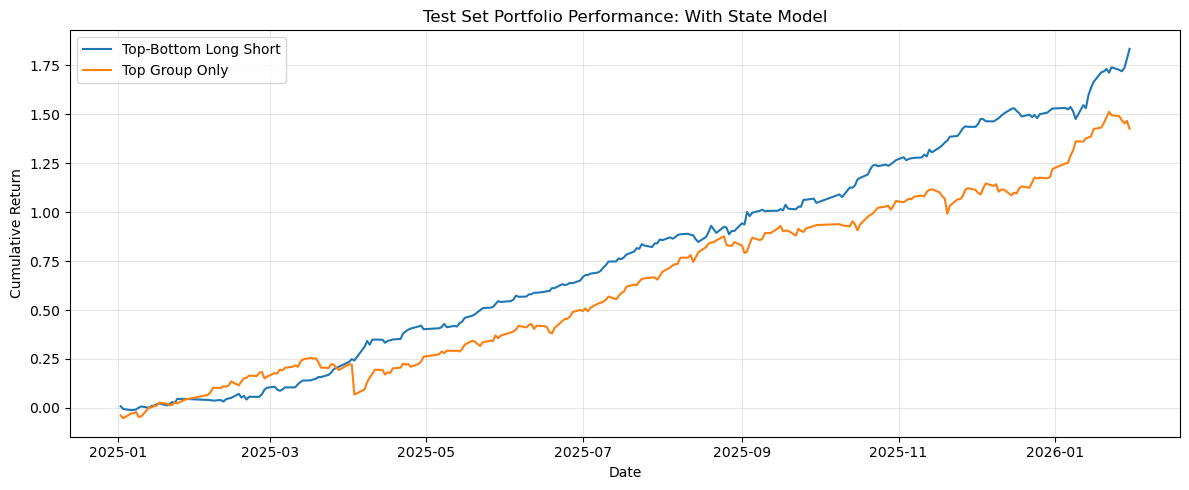

图片已保存： /Users/runtianzhou/Turing_AI_v2/figures/test_long_short_cumret_v2.png


In [60]:
# Cell 16：画 Top 组与 Top-Bottom 多空累计收益

plot_grp = grp_state.copy().sort_values("date")

plot_grp["cum_long_short"] = (
    1 + plot_grp["long_short"].fillna(0)
).cumprod() - 1

plot_grp["cum_top"] = (
    1 + plot_grp["top"].fillna(0)
).cumprod() - 1

plt.figure(figsize=(12, 5))
plt.plot(
    plot_grp["date"],
    plot_grp["cum_long_short"],
    label="Top-Bottom Long Short",
)

plt.plot(
    plot_grp["date"],
    plot_grp["cum_top"],
    label="Top Group Only",
)

plt.title("Test Set Portfolio Performance: With State Model")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "test_long_short_cumret_v2.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("图片已保存：", fig_path)

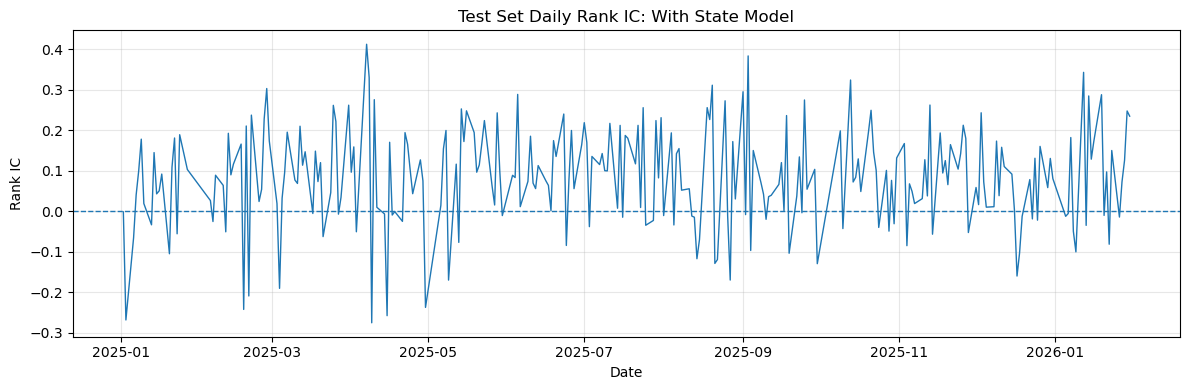

图片已保存： /Users/runtianzhou/Turing_AI_v2/figures/test_ic_timeseries_v2.png


In [61]:
# Cell 17：画 Test 集逐日 Rank IC

plot_ic = ic_state.copy().sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(
    plot_ic["date"],
    plot_ic["rank_ic"],
    linewidth=1.0,
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Test Set Daily Rank IC: With State Model")
plt.xlabel("Date")
plt.ylabel("Rank IC")
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "test_ic_timeseries_v2.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("图片已保存：", fig_path)

In [62]:
# Cell 18：生成文字报告

def pct(x):
    if pd.isna(x):
        return "nan"
    return f"{x * 100:.3f}%"


report = []

report.append("# 个股截面预测 V2：Test 集预测效果报告\n\n")

report.append("## 一、任务说明\n\n")
report.append(
    "本版本按照老师要求，从单纯的市场状态识别转为监督预测任务。"
    "目标是使用日线数据预测个股未来1日涨跌幅和未来1日是否上涨。\n\n"
)

report.append("预测形式为：\n\n")
report.append("X_t, Z_t -> r_{t+1}\n\n")

report.append(
    "其中，X_t 表示个股和市场日线特征，Z_t 表示市场状态变量，"
    "r_{t+1} 表示未来1日收益率。\n\n"
)

report.append("## 二、Train/Test 切分\n\n")
report.append(f"训练集：{train_df['date'].min().date()} 至 {train_df['date'].max().date()}\n\n")
report.append(f"测试集：{test_df['date'].min().date()} 至 {test_df['date'].max().date()}\n\n")

report.append("## 三、Test 集指标\n\n")

for _, r in metrics_df.iterrows():
    report.append(f"### {r['model']}\n\n")
    report.append(f"- 样本数：{int(r['n_obs'])}\n")
    report.append(f"- 交易日数：{int(r['n_days'])}\n")
    report.append(f"- Overall IC：{r['overall_ic']:.4f}\n")
    report.append(f"- Overall Rank IC：{r['overall_rank_ic']:.4f}\n")
    report.append(f"- Daily IC Mean：{r['daily_ic_mean']:.4f}\n")
    report.append(f"- Daily IC t值：{r['daily_ic_t']:.4f}\n")
    report.append(f"- Daily Rank IC Mean：{r['daily_rank_ic_mean']:.4f}\n")
    report.append(f"- Daily Rank IC t值：{r['daily_rank_ic_t']:.4f}\n")
    report.append(f"- 方向准确率：{pct(r['direction_accuracy'])}\n")
    report.append(f"- AUC：{r['auc']:.4f}\n")
    report.append(f"- Top组日均收益：{pct(r['top_group_mean_ret'])}\n")
    report.append(f"- Top-Bottom日均收益：{pct(r['long_short_mean_ret'])}\n")
    report.append(f"- Top-Bottom日频Sharpe：{r['long_short_sharpe_daily']:.4f}\n\n")

report.append("## 四、结果解释\n\n")
report.append(
    "本版本更贴近量化研究的核心问题：不是只解释市场处于什么状态，"
    "而是在 Test 集上直接评估未来涨跌幅和涨跌方向预测效果。"
    "重点关注 Daily Rank IC、方向准确率、AUC、Top组收益和Top-Bottom多空收益。\n\n"
)

report.append(
    "如果 with_state 模型相对 base_no_state 在 Daily Rank IC、AUC 或分组收益上有所提升，"
    "说明市场状态变量对个股收益预测具有增量信息。"
    "如果提升不明显，则说明当前状态变量对预测帮助有限，需要继续改进特征、模型或预测目标。\n"
)

report_text = "".join(report)

report_path = REPORT_DIR / "prediction_v2_report.md"
report_path.write_text(report_text, encoding="utf-8")

print(report_text)
print("报告已保存：", report_path)

# 个股截面预测 V2：Test 集预测效果报告

## 一、任务说明

本版本按照老师要求，从单纯的市场状态识别转为监督预测任务。目标是使用日线数据预测个股未来1日涨跌幅和未来1日是否上涨。

预测形式为：

X_t, Z_t -> r_{t+1}

其中，X_t 表示个股和市场日线特征，Z_t 表示市场状态变量，r_{t+1} 表示未来1日收益率。

## 二、Train/Test 切分

训练集：2020-01-02 至 2024-12-31

测试集：2025-01-02 至 2026-01-30

## 三、Test 集指标

### base_no_state

- 样本数：1351492
- 交易日数：263
- Overall IC：0.0750
- Overall Rank IC：0.0406
- Daily IC Mean：0.1249
- Daily IC t值：24.8941
- Daily Rank IC Mean：0.0794
- Daily Rank IC t值：9.4485
- 方向准确率：51.968%
- AUC：0.5351
- Top组日均收益：0.326%
- Top-Bottom日均收益：0.392%
- Top-Bottom日频Sharpe：0.4038

### with_state

- 样本数：1351492
- 交易日数：263
- Overall IC：0.0638
- Overall Rank IC：0.0494
- Daily IC Mean：0.1242
- Daily IC t值：25.5822
- Daily Rank IC Mean：0.0842
- Daily Rank IC t值：11.2406
- 方向准确率：54.195%
- AUC：0.5622
- Top组日均收益：0.348%
- Top-Bottom日均收益：0.401%
- Top-Bottom日频Sharpe：0.4555

## 四、结果解释

本版本更贴近量化研究的核心问题：不是只解释市场处于什么状态，而是在 Test 集上直接评估未来涨跌幅和涨跌方向预测效果。重点关注 Daily Rank IC、方向准确率、AUC、Top组收益和Top-Bottom多空收益。

如果 with_state 模型相对 base_no_sta